In [19]:
import pandas as pd
import json

In [25]:
from pathlib import Path

base_dir = PROJECT_ROOT if 'PROJECT_ROOT' in globals() else Path.cwd()
candidates = [
    base_dir / 'data' / 'raw' / 'train-item-views.csv',
    base_dir.parent / 'data' / 'raw' / 'train-item-views.csv',
    Path.cwd() / 'data' / 'raw' / 'train-item-views.csv',
    Path.cwd().parent / 'data' / 'raw' / 'train-item-views.csv',
]

data_path = next((p for p in candidates if p.exists()), candidates[0])
train_item_view = pd.read_csv(data_path, sep=';')
train_item_view.head()

,sessionId,userId,itemId,timeframe,eventdate
0,1,NaN,81766,526309,2016-05-09
1,1,NaN,31331,1031018,2016-05-09
2,1,NaN,32118,243569,2016-05-09
3,1,NaN,9654,75848,2016-05-09
4,1,NaN,32627,1112408,2016-05-09


In [29]:
# dataset của srgnn paper
base_dir = PROJECT_ROOT if 'PROJECT_ROOT' in globals() else Path.cwd()
candidates = [
    base_dir / 'data' / 'raw' / 'sample_train-item-views.csv',
    base_dir.parent / 'data' / 'raw' / 'sample_train-item-views.csv',
    Path.cwd() / 'data' / 'raw' / 'sample_train-item-views.csv',
    Path.cwd().parent / 'data' / 'raw' / 'sample_train-item-views.csv',
]

sample_path = next((p for p in candidates if p.exists()), candidates[0])
sample = pd.read_csv(sample_path, sep=';')
sample.head()

,session_id,user_id,item_id,timeframe,eventdate
0,1,NaN,81766,526309,2016-05-09
1,1,NaN,31331,1031018,2016-05-09
2,1,NaN,32118,243569,2016-05-09
3,1,NaN,9654,75848,2016-05-09
4,1,NaN,32627,1112408,2016-05-09


In [30]:
# in ra các userId có giá trị null
train_item_view[train_item_view['userId'].isnull()]

,sessionId,userId,itemId,timeframe,eventdate
0,1,NaN,81766,526309,2016-05-09
1,1,NaN,31331,1031018,2016-05-09
2,1,NaN,32118,243569,2016-05-09
3,1,NaN,9654,75848,2016-05-09
4,1,NaN,32627,1112408,2016-05-09
...,...,...,...,...,...
1235374,600683,NaN,120370,248101,2016-03-25
1235375,600684,NaN,42906,632853,2016-04-14
1235376,600684,NaN,33312,643522,2016-04-14
1235377,600684,NaN,33312,52621,2016-04-14


In [31]:
train_item_view[train_item_view['userId'].isnull()].count()

sessionId    862389
userId            0
itemId       862389
timeframe    862389
eventdate    862389
dtype: int64

In [32]:
sample.shape

(12391, 5)

Dữ liệu từ sample train item views là sample của bảng view

In [33]:
sample.describe()

,session_id,user_id,item_id,timeframe
count,12391.000000,4710.000000,12391.000000,1.239100e+04
mean,2003.805423,1630.960934,72182.785651,3.279420e+05
std,1156.351450,10375.232174,92603.552342,3.261357e+05
min,1.000000,2.000000,41.000000,2.675000e+03
25%,1000.500000,445.000000,12953.000000,5.255350e+04
50%,2037.000000,888.000000,36035.000000,2.110610e+05
75%,2975.000000,1292.000000,85094.500000,5.203090e+05
max,3999.000000,231213.000000,666146.000000,1.199958e+06


In [ ]:
sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12391 entries, 0 to 12390
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   session_id  12391 non-null  int64  
 1   user_id     4710 non-null   float64
 2   item_id     12391 non-null  int64  
 3   timeframe   12391 non-null  int64  
 4   eventdate   12391 non-null  object 
dtypes: float64(1), int64(3), object(1)
memory usage: 484.2+ KB


In [ ]:
sample[sample['user_id'].notnull()]

,session_id,user_id,item_id,timeframe,eventdate
164,48,2.0,24764,8863,2016-04-09
165,48,2.0,24764,496381,2016-04-09
166,48,2.0,24764,265216,2016-04-09
167,48,2.0,24764,519975,2016-04-09
168,48,2.0,24764,456437,2016-04-09
...,...,...,...,...,...
12364,3990,1747.0,88235,780751,2016-01-24
12365,3990,1747.0,77554,593789,2016-01-24
12366,3990,1747.0,6376,811586,2016-01-24
12367,3990,1747.0,13937,622537,2016-01-24


dữ liệu srgnn trong paper sử dụng của non-anonymous user vì không quan tâm đến user_id, chỉ quan tâm đến hành động của người dùng và nó cũng phù hợp với thực tế của một website

In [34]:
# tỷ lệ anonymous user và non-anonymous user trong tập dữ liệu train_item_view
num_anonymous_users = train_item_view[train_item_view['userId'].isnull()].shape[0]
num_non_anonymous_users = train_item_view[train_item_view['userId'].notnull()].shape[0]
total_users = num_anonymous_users + num_non_anonymous_users
print(f"Number of anonymous users: {num_anonymous_users} ({num_anonymous_users/total_users:.2%})")
print(f"Number of non-anonymous users: {num_non_anonymous_users} ({num_non_anonymous_users/total_users:.2%})")    

Number of anonymous users: 862389 (69.81%)
Number of non-anonymous users: 372991 (30.19%)


In [35]:
# session length của anonymous user và non-anonymous user trong tập dữ liệu train_item_view
session_length_anonymous = train_item_view[train_item_view['userId'].isnull()].groupby('sessionId').size()
session_length_non_anonymous = train_item_view[train_item_view['userId'].notnull()].groupby('sessionId').size()
print(f"Average session length for anonymous users: {session_length_anonymous.mean():.2f}")
print(f"Average session length for non-anonymous users: {session_length_non_anonymous.mean():.2f}")

Average session length for anonymous users: 3.98
Average session length for non-anonymous users: 3.96


Data có số lượng session và sesion length với anonymous user và non-anonymous user cân bằng --> không cần loại bỏ identified user --> model học tốt hơn về bias vì trong thực tế không phải lúc nào cũng chỉ có anonymous user truy cập và RS-GNN chỉ quan tâm đến session không quan tâm đến userid

In [36]:
# in ra session length dài nhất và sessions length ngắn nhất của anonymous user và non-anonymous user trong tập dữ liệu train_item_view
max_session_length_anonymous = session_length_anonymous.max()
min_session_length_anonymous = session_length_anonymous.min()
max_session_length_non_anonymous = session_length_non_anonymous.max()
min_session_length_non_anonymous = session_length_non_anonymous.min()
print(f"Max session length for anonymous users: {max_session_length_anonymous}")
print(f"Min session length for anonymous users: {min_session_length_anonymous}")
print(f"Max session length for non-anonymous users: {max_session_length_non_anonymous}")
print(f"Min session length for non-anonymous users: {min_session_length_non_anonymous}")

Max session length for anonymous users: 87
Min session length for anonymous users: 1
Max session length for non-anonymous users: 81
Min session length for non-anonymous users: 1


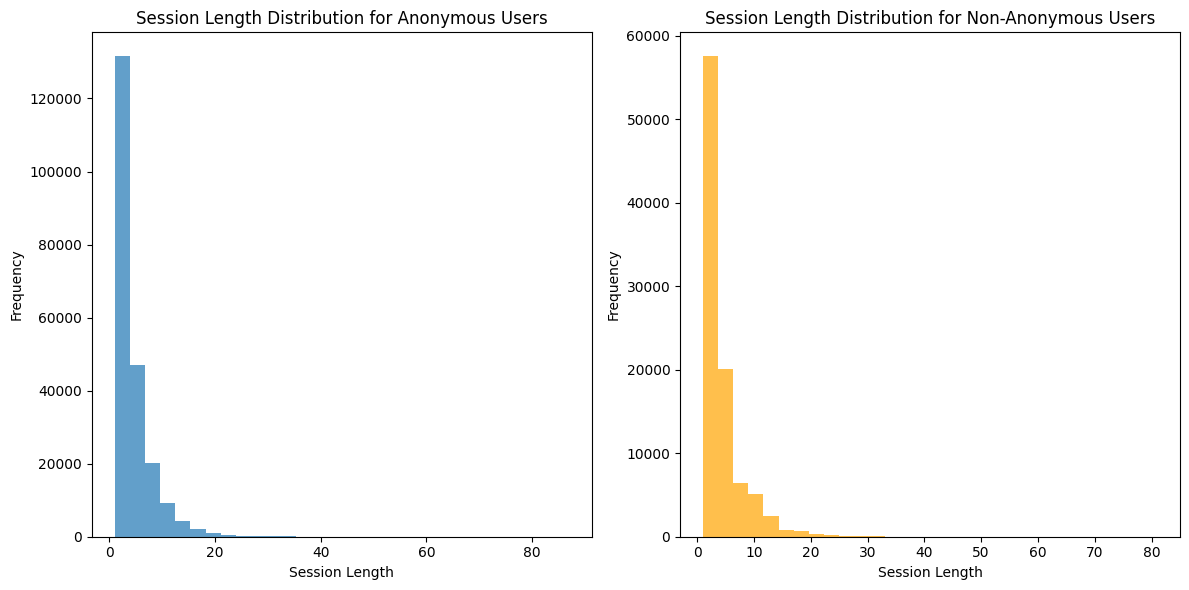

In [37]:
# distribution của session length của anonymous user và non-anonymous user trong tập dữ liệu train_item_view
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(session_length_anonymous, bins=30, alpha=0.7, label='Anonymous Users')
plt.title('Session Length Distribution for Anonymous Users')
plt.xlabel('Session Length')
plt.ylabel('Frequency')
plt.subplot(1, 2, 2)
plt.hist(session_length_non_anonymous, bins=30, alpha=0.7, label='Non-Anonymous Users', color='orange')
plt.title('Session Length Distribution for Non-Anonymous Users')
plt.xlabel('Session Length')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


In [38]:
# % session length <= 1 trong tập dữ liệu train_item_views không phân biệt anaonymous user và non-anonymous user
short_sessions = session_length_anonymous[session_length_anonymous <= 1].count() + session_length_non_anonymous[session_length_non_anonymous <= 1].count()
total_sessions = session_length_anonymous.count() + session_length_non_anonymous.count()
print(f"Percentage of sessions with length <= 1: {short_sessions/total_sessions:.2%}") 

# % session length = 2 trong tập dữ liệu train-item-views không phân biệt anaonymous user và non-anonymous user
short_sessions = session_length_anonymous[session_length_anonymous == 2].count() + session_length_non_anonymous[session_length_non_anonymous == 2].count()
total_sessions = session_length_anonymous.count() + session_length_non_anonymous.count()
print(f"Percentage of sessions with length = 2: {short_sessions/total_sessions:.2%}")


Percentage of sessions with length <= 1: 29.29%
Percentage of sessions with length = 2: 18.55%


In [39]:
# calculate the quantile of session length trong tập dữ liệu train_item_view không phân biệt anonymous user và non-anonymous user
session_length = pd.concat([session_length_anonymous, session_length_non_anonymous])
quantiles = session_length.quantile([0.25, 0.5, 0.75])
print(f"25th percentile of session length: {quantiles[0.25]}")
print(f"50th percentile of session length: {quantiles[0.5]}")
print(f"75th percentile of session length: {quantiles[0.75]}")

# % session length <= 20 trong tập dữ liệu train_item_views không phân biệt anaonymous user và non-anonymous user
short_sessions = session_length_anonymous[session_length_anonymous <= 20].count() + session_length_non_anonymous[session_length_non_anonymous <= 20].count()
total_sessions = session_length_anonymous.count() + session_length_non_anonymous.count()
print(f"Percentage of sessions with length <= 20: {short_sessions/total_sessions:.2%}")

25th percentile of session length: 1.0
50th percentile of session length: 3.0
75th percentile of session length: 5.0
Percentage of sessions with length <= 20: 99.32%


In [48]:
# % session length <= 10 trong tập dữ liệu train_item_views không phân biệt anaonymous user và non-anonymous user
short_sessions = session_length_anonymous[session_length_anonymous <= 10].count() + session_length_non_anonymous[session_length_non_anonymous <= 10].count()
total_sessions = session_length_anonymous.count() + session_length_non_anonymous.count()
print(f"Percentage of sessions with length <= 10: {short_sessions/total_sessions:.2%}")
# % session length <= 15 trong tập dữ liệu train_item_views không phân biệt anaonymous user và non-anonymous user
short_sessions_15 = session_length_anonymous[session_length_anonymous <= 15].count() + session_length_non_anonymous[session_length_non_anonymous <= 15].count() 
total_sessions = session_length_anonymous.count() + session_length_non_anonymous.count()
print(f"Percentage of sessions with length <= 15: {short_sessions_15/total_sessions:.2%}")
# % session length <= 20 trong tập dữ liệu train_item_views không phân biệt anaonymous user và non-anonymous user
short_sessions_20 = session_length_anonymous[session_length_anonymous <= 20].count() + session_length_non_anonymous[session_length_non_anonymous <= 20].count()
print(f"Percentage of sessions with length <= 20: {short_sessions_20/total_sessions:.2%}")
# % session length <= 25 trong tập dữ liệu train_item_views không phân biệt anaonymous user và non-anonymous user
short_sessions_25 = session_length_anonymous[session_length_anonymous <= 25].count() + session_length_non_anonymous[session_length_non_anonymous <= 25].count()
print(f"Percentage of sessions with length <= 25: {short_sessions_25/total_sessions:.2%}")  
# % session length <= 30 trong tập dữ liệu train_item_views không phân biệt anaonymous user và non-anonymous user
short_sessions_30 = session_length_anonymous[session_length_anonymous <= 30].count() + session_length_non_anonymous[session_length_non_anonymous <= 30].count()
print(f"Percentage of sessions with length <= 30: {short_sessions_30/total_sessions:.2%}")  

Percentage of sessions with length <= 10: 93.44%
Percentage of sessions with length <= 15: 97.97%
Percentage of sessions with length <= 20: 99.32%
Percentage of sessions with length <= 25: 99.74%
Percentage of sessions with length <= 30: 99.90%


In [44]:
# in ra số lượng session có 1 item được view nhiều lần (>=3) liên tiếp (ví dụ: A--> A --> A --> B) trong data train_item_view không phân biệt anonymous user và non-anonymous user
def count_repeated_views(df):
    count = 0
    for session_id, group in df.groupby('sessionId'):
        item_sequence = group['itemId'].tolist()
        for i in range(1, len(item_sequence) - 1):
            if item_sequence[i] == item_sequence[i-1] == item_sequence[i+1]:
                count += 1
                break  # Count each session only once
    return count
num_repeated_views = count_repeated_views(train_item_view)
print(f"Number of sessions with at least one item viewed 3 or more times consecutively: {num_repeated_views}")
print(f'Percentage of sessions with at least one item viewed 3 or more times consecutively: {num_repeated_views/total_sessions:.2%}')

Number of sessions with at least one item viewed 3 or more times consecutively: 24493
Percentage of sessions with at least one item viewed 3 or more times consecutively: 7.88%


Bằng cách kiểm tra xem có sự khác biệt về thời gian giữa các lần view của cùng một item trong cùng một session, các sản phẩm được view nhiều lần liên tiếp là user chủ động xem lại sản phẩm đó chứ không phải do reload trang web hoặc lỗi hệ thống. Nếu thời gian giữa các lần view là ngắn (ví dụ: dưới 1 phút), thì có thể là do reload trang web hoặc lỗi hệ thống. Nếu thời gian giữa các lần view là dài hơn (ví dụ: trên 1 phút), thì có thể là do user chủ động xem lại sản phẩm đó.

In [23]:
def check_time_difference(df):
    for session_id, group in df.groupby('sessionId'):
        # Parse timeframe robustly (ISO string, datetime, or epoch milliseconds/seconds)
        numeric_ts = pd.to_numeric(group['timeframe'], errors='coerce')
        if numeric_ts.notna().all():
            median_ts = numeric_ts.median()
            unit = 'ms' if median_ts > 1e11 else 's'
            timestamps = pd.to_datetime(numeric_ts, unit=unit, errors='coerce', utc=True)
        else:
            timestamps = pd.to_datetime(group['timeframe'], errors='coerce', utc=True)

        group = group.assign(_parsed_time=timestamps).dropna(subset=['_parsed_time']).sort_values('_parsed_time')
        if len(group) < 3:
            continue

        item_sequence = group['itemId'].tolist()
        timestamp_sequence = group['_parsed_time'].tolist()

        for i in range(1, len(item_sequence) - 1):
            if item_sequence[i] == item_sequence[i - 1] == item_sequence[i + 1]:
                time_diff_1 = (timestamp_sequence[i] - timestamp_sequence[i - 1]).total_seconds()
                time_diff_2 = (timestamp_sequence[i + 1] - timestamp_sequence[i]).total_seconds()

                if time_diff_1 < 60 and time_diff_2 < 60:
                    return "Likely due to reload or system error"
                else:
                    return "Likely due to user actively viewing the product again"

    return "No repeated views found"

result = check_time_difference(train_item_view)
print(result)

Likely due to user actively viewing the product again


User chủ động xem lại sản phẩm --> đó là hành vi khách hàng --> không cần loại bỏ những sản phẩm được view liên tiếp nhiều lần

# Data Processing

5 Stage to process data:
1. Ingest
2. Validate
3. Preprocess
4. Split
5. Build training examples

In [24]:
from pathlib import Path
import json
import sys

import pandas as pd

# Ensure project root is importable when running notebook directly
PROJECT_ROOT = Path.cwd().resolve()
if (PROJECT_ROOT / 'notebooks').exists():
    PROJECT_ROOT = PROJECT_ROOT
elif (PROJECT_ROOT.parent / 'notebooks').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
else:
    raise RuntimeError('Please open the notebook from project root or notebooks folder.')

SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

CONFIG_PATH = PROJECT_ROOT / 'configs' / 'data_config.yaml'
PARAMS_PATH = PROJECT_ROOT / 'params.yaml'

print('PROJECT_ROOT =', PROJECT_ROOT)
print('CONFIG_PATH  =', CONFIG_PATH)
print('PARAMS_PATH  =', PARAMS_PATH)

PROJECT_ROOT = D:\SR_GNN\recsys-group-project
CONFIG_PATH  = D:\SR_GNN\recsys-group-project\configs\data_config.yaml
PARAMS_PATH  = D:\SR_GNN\recsys-group-project\params.yaml


In [5]:
# Optional one-time install if imports fail
# %pip install -e .

from pathlib import Path
import os
import sys

# Make this cell self-contained even if previous setup cell was not run
if 'PROJECT_ROOT' not in globals():
    PROJECT_ROOT = Path.cwd().resolve()
    if (PROJECT_ROOT / 'notebooks').exists():
        PROJECT_ROOT = PROJECT_ROOT
    elif (PROJECT_ROOT.parent / 'notebooks').exists():
        PROJECT_ROOT = PROJECT_ROOT.parent
    else:
        raise RuntimeError('Please open the notebook from project root or notebooks folder.')

# Ensure relative paths in src pipeline resolve from project root
os.chdir(PROJECT_ROOT)

if 'CONFIG_PATH' not in globals():
    CONFIG_PATH = PROJECT_ROOT / 'configs' / 'data_config.yaml'
if 'PARAMS_PATH' not in globals():
    PARAMS_PATH = PROJECT_ROOT / 'params.yaml'

SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from recsys.data.stages import (
    run_ingest_stage,
    run_validate_stage,
    run_preprocess_stage,
    run_split_stage,
    run_build_examples_stage,
)

required_paths = [
    PROJECT_ROOT / 'data' / 'raw' / 'train-item-views.csv',
    CONFIG_PATH,
    PARAMS_PATH,
]

for p in required_paths:
    print(f'{p}:', 'OK' if p.exists() else 'MISSING')

for folder in [
    PROJECT_ROOT / 'data' / 'interim',
    PROJECT_ROOT / 'data' / 'processed',
    PROJECT_ROOT / 'metrics',
]:
    folder.mkdir(parents=True, exist_ok=True)

print('CWD =', Path.cwd())
print('Ready to run data stages.')

D:\SR_GNN\recsys-group-project\data\raw\train-item-views.csv: OK
D:\SR_GNN\recsys-group-project\configs\data_config.yaml: OK
D:\SR_GNN\recsys-group-project\params.yaml: OK
CWD = D:\SR_GNN\recsys-group-project
Ready to run data stages.


In [7]:
# Stage 1: Ingest
import os
from pathlib import Path

# Safe guard: make sure stage runs from project root for relative paths in config
os.chdir(PROJECT_ROOT)
print('CWD =', Path.cwd())

ingest_outputs = run_ingest_stage(config_path=CONFIG_PATH, params_path=PARAMS_PATH)
ingest_outputs

2026-04-18 11:26:45.903 | INFO     | recsys.data.ingest:_load_csv:33 - Loading data\raw\train-item-views.csv


CWD = D:\SR_GNN\recsys-group-project


2026-04-18 11:26:47.600 | INFO     | recsys.data.ingest:ingest:57 - Saved 1,235,380 item-view interactions to data\interim\interactions.parquet
2026-04-18 11:26:47.655 | INFO     | recsys.data.ingest:ingest:71 - Saved ingest report to metrics\ingest_report.json


{'interactions': 'data\\interim\\interactions.parquet',
 'ingest_report': 'metrics/ingest_report.json'}

In [8]:
# Stage 2: Validate
validate_outputs = run_validate_stage(config_path=CONFIG_PATH)
validate_outputs

2026-04-18 11:27:07.849 | INFO     | recsys.data.validator:validate_schema:87 - ✓ All required columns present
2026-04-18 11:27:08.002 | WARNING  | recsys.data.validator:validate_semantics:166 - ✗ Semantic validation issues found:
2026-04-18 11:27:08.002 | WARNING  | recsys.data.validator:validate_semantics:168 -   - Found 90694 sessions with < 2 items
2026-04-18 11:27:08.002 | WARNING  | recsys.data.validator:validate_semantics:168 -   - Found 2108 sessions with > 20 items


{'validation_report': 'data/validation_report.json'}

In [9]:
# Stage 3: Preprocess
preprocess_outputs = run_preprocess_stage(config_path=CONFIG_PATH)
preprocess_outputs

2026-04-18 11:27:19.582 | INFO     | recsys.data.preprocessor:transform:53 - Starting with 1,235,380 rows
2026-04-18 11:27:20.521 | INFO     | recsys.data.preprocessor:transform:114 - ✓ After preprocessing: 1,235,380 rows
2026-04-18 11:27:20.693 | INFO     | recsys.data.preprocessor:filter_sessions:147 - Dropped 90,694 rows from sessions with < 2 items
2026-04-18 11:27:21.013 | INFO     | recsys.data.preprocessor:filter_sessions:165 - Trimmed 12,553 rows from 2,108 sessions longer than 20 items
2026-04-18 11:27:21.036 | INFO     | recsys.data.preprocessor:filter_sessions:171 - Sessions: 310,324 → 219,630 (removed 90,694)
2026-04-18 11:27:21.165 | INFO     | recsys.data.preprocessor:filter_items:206 - Dropped 139,500 rows from items with < 5 interactions
2026-04-18 11:27:21.189 | INFO     | recsys.data.preprocessor:filter_items:223 - Items: 120,889 → 42,778 (removed 78,111)
2026-04-18 11:27:21.584 | INFO     | recsys.data.preprocessor:filter_sessions:147 - Dropped 11,433 rows from sessi

{'clean_interactions': 'data\\interim\\clean_interactions.parquet'}

In [10]:
# Stage 4: Split
split_outputs = run_split_stage(config_path=CONFIG_PATH)
split_outputs

2026-04-18 11:27:34.864 | INFO     | recsys.data.splitter:split_diginetica_legacy:210 - Temporal split (diginetica-legacy): train=839,971 val=54,830 test=76,249
2026-04-18 11:27:34.864 | INFO     | recsys.data.splitter:split_diginetica_legacy:214 - Date boundaries: split=2016-05-25 00:00:00+00:00 max=2016-06-01 00:00:00+00:00


{'train_interactions': 'data\\interim\\train_interactions.parquet',
 'val_interactions': 'data\\interim\\val_interactions.parquet',
 'test_interactions': 'data\\interim\\test_interactions.parquet'}

In [11]:
# Stage 5: Build examples + vocabulary + stats
build_outputs = run_build_examples_stage(config_path=CONFIG_PATH)
build_outputs

2026-04-18 11:27:46.686 | INFO     | recsys.data.training_examples:build_from_interactions:70 - ✓ Built vocabulary with 42655 items
2026-04-18 11:28:07.729 | INFO     | recsys.data.training_examples:build_graph_examples:346 - Generated 665,078 graph examples from 174,893 sessions
2026-04-18 11:28:09.647 | INFO     | recsys.data.training_examples:build_graph_examples:346 - Generated 42,949 graph examples from 11,633 sessions
2026-04-18 11:28:11.764 | INFO     | recsys.data.training_examples:build_graph_examples:346 - Generated 59,725 graph examples from 15,970 sessions
2026-04-18 11:28:14.306 | INFO     | recsys.data.training_examples:save:127 - ✓ Vocabulary saved to data\processed\item_vocab.json


{'train_examples': 'data\\processed\\train_examples.parquet',
 'val_examples': 'data\\processed\\val_examples.parquet',
 'test_examples': 'data\\processed\\test_examples.parquet',
 'vocab': 'data\\processed\\item_vocab.json',
 'stats': 'data\\processed\\data_stats.json'}

In [12]:
all_outputs = {}
all_outputs.update(ingest_outputs)
all_outputs.update(validate_outputs)
all_outputs.update(preprocess_outputs)
all_outputs.update(split_outputs)
all_outputs.update(build_outputs)

print('Artifacts generated:')
for name, rel_path in all_outputs.items():
    abs_path = PROJECT_ROOT / rel_path
    print(f'- {name}: {abs_path} | exists={abs_path.exists()}')

Artifacts generated:
- interactions: D:\SR_GNN\recsys-group-project\data\interim\interactions.parquet | exists=True
- ingest_report: D:\SR_GNN\recsys-group-project\metrics\ingest_report.json | exists=True
- validation_report: D:\SR_GNN\recsys-group-project\data\validation_report.json | exists=True
- clean_interactions: D:\SR_GNN\recsys-group-project\data\interim\clean_interactions.parquet | exists=True
- train_interactions: D:\SR_GNN\recsys-group-project\data\interim\train_interactions.parquet | exists=True
- val_interactions: D:\SR_GNN\recsys-group-project\data\interim\val_interactions.parquet | exists=True
- test_interactions: D:\SR_GNN\recsys-group-project\data\interim\test_interactions.parquet | exists=True
- train_examples: D:\SR_GNN\recsys-group-project\data\processed\train_examples.parquet | exists=True
- val_examples: D:\SR_GNN\recsys-group-project\data\processed\val_examples.parquet | exists=True
- test_examples: D:\SR_GNN\recsys-group-project\data\processed\test_examples.parq

In [17]:
train_examples_path = PROJECT_ROOT / build_outputs['train_examples']
val_examples_path = PROJECT_ROOT / build_outputs['val_examples']
test_examples_path = PROJECT_ROOT / build_outputs['test_examples']
vocab_path = PROJECT_ROOT / build_outputs['vocab']
stats_path = PROJECT_ROOT / build_outputs['stats']

train_examples = pd.read_parquet(train_examples_path)
val_examples = pd.read_parquet(val_examples_path)
test_examples = pd.read_parquet(test_examples_path)

print('Shapes:')
print('train_examples:', train_examples.shape)
print('val_examples  :', val_examples.shape)
print('test_examples :', test_examples.shape)

with open(vocab_path, 'r', encoding='utf-8') as f:
    vocab_json = json.load(f)

with open(stats_path, 'r', encoding='utf-8') as f:
    stats_json = json.load(f)

print('vocab size:', vocab_json.get('size'))
print('stats keys:', list(stats_json.keys()))
train_examples.head()

Shapes:
train_examples: (665078, 7)
val_examples  : (42949, 7)
test_examples : (59725, 7)
vocab size: 42655
stats keys: ['config_file', 'train', 'val', 'test', 'vocab_size']


,x,edge_index,alias_inputs,item_seq_len,pos_items,session_id,eventdate
0,"[1, 2, 3, 4, 5, 6, 7, 8]","[[0, 1, 2, 3, 4, 5, 6], [1, 2, 3, 4, 5, 6, 7]]","[0, 1, 2, 3, 4, 5, 6, 7]",8,9,1,2016-05-09 00:00:00+00:00
1,"[1, 2, 3, 4, 5, 6, 7]","[[0, 1, 2, 3, 4, 5], [1, 2, 3, 4, 5, 6]]","[0, 1, 2, 3, 4, 5, 6]",7,8,1,2016-05-09 00:00:00+00:00
2,"[1, 2, 3, 4, 5, 6]","[[0, 1, 2, 3, 4], [1, 2, 3, 4, 5]]","[0, 1, 2, 3, 4, 5]",6,7,1,2016-05-09 00:00:00+00:00
3,"[1, 2, 3, 4, 5]","[[0, 1, 2, 3], [1, 2, 3, 4]]","[0, 1, 2, 3, 4]",5,6,1,2016-05-09 00:00:00+00:00
4,"[1, 2, 3, 4]","[[0, 1, 2], [1, 2, 3]]","[0, 1, 2, 3]",4,5,1,2016-05-09 00:00:00+00:00
